# Otimizando a Experiência do Cliente no E-commerce Brasileiro: 
## Uma Análise de 100 mil Pedidos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DADOS_TRATADO, geolocation

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_TRATADO)

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752,mogi das cruzes,SP


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  string        
 1   customer_id                    113425 non-null  string        
 2   order_status                   113425 non-null  category      
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   customer_unique_id             113425 non-null  string        
 9   customer_zip_code_prefix       113425 non-null  string        
 10  customer_city                  113425 non-null  string        
 11  

In [4]:
df.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
customer_unique_id               96096
customer_zip_code_prefix         14994
customer_city                     4119
customer_state                      27
order_item_id                       21
product_id                       32951
seller_id                         3095
shipping_limit_date              93318
price                             5968
freight_value                     6999
product_category_name               73
product_name_lenght                 66
product_description_lenght        2960
product_photos_qty                  19
product_weight_g                  2204
product_length_cm                   99
product_height_cm                  102
product_width_cm         

In [5]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,113425,113264,111457,110196,113425,112650.000000,112650,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000
mean,2017-12-31 12:25:41.686480128,2017-12-31 22:40:56.664121088,2018-01-05 02:17:27.942515968,2018-01-14 13:25:24.023939328,2018-01-24 08:22:34.875909120,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000,2016-09-19 00:15:34,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,2017-09-13 11:05:49,2017-09-13 20:25:10.500000,2017-09-18 20:37:00,2017-09-26 20:09:44.500000,2017-10-04 00:00:00,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,2018-01-19 10:37:45,2018-01-19 16:59:52.500000,2018-01-24 18:44:33,2018-02-02 20:57:23,2018-02-15 00:00:00,1.000000,2018-01-26 13:59:35,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,2018-05-04 14:22:16,2018-05-04 18:31:38.500000,2018-05-08 13:20:00,2018-05-15 20:09:21.500000,2018-05-25 00:00:00,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000
std,NaN,NaN,NaN,NaN,NaN,0.705124,NaN,183.633928,15.806405,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268


In [6]:
df.describe(exclude='number')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,shipping_limit_date,product_category_name,seller_zip_code_prefix,seller_city,seller_state
count,113425,113425,113425,113425,113264,111457,110196,113425,113425,113425,113425,113425,112650,112650,112650,111047,112650,112650,112650
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,96096,14994,4119,27,32951,3095,NaN,73,2246,611,23
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,NaN,NaN,NaN,NaN,NaN,c8460e4251689ba205045f3ea17884a1,22790,sao paulo,SP,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,cama_mesa_banho,14940,sao paulo,SP
freq,21,21,110197,NaN,NaN,NaN,NaN,NaN,24,154,17946,47820,527,2033,NaN,11115,7750,27983,80342
mean,NaN,NaN,NaN,2017-12-31 12:25:41.686480128,2017-12-31 22:40:56.664121088,2018-01-05 02:17:27.942515968,2018-01-14 13:25:24.023939328,2018-01-24 08:22:34.875909120,NaN,NaN,NaN,NaN,NaN,NaN,2018-01-07 15:36:52.192685312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2016-09-19 00:15:34,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2017-09-13 11:05:49,2017-09-13 20:25:10.500000,2017-09-18 20:37:00,2017-09-26 20:09:44.500000,2017-10-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2017-09-20 20:57:27.500000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2018-01-19 10:37:45,2018-01-19 16:59:52.500000,2018-01-24 18:44:33,2018-02-02 20:57:23,2018-02-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2018-01-26 13:59:35,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2018-05-04 14:22:16,2018-05-04 18:31:38.500000,2018-05-08 13:20:00,2018-05-15 20:09:21.500000,2018-05-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2018-05-10 14:34:00.750000128,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2020-04-09 22:35:08,NaN,NaN,NaN,NaN


In [7]:
with pd.option_context("display.max_columns", None):
    display(df.head(5))

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752,mogi das cruzes,SP


### Separando as colunas por tipos de variáveis

Qual a saúde financeira do marketplace? (Evolução mensal de vendas e ticket médio)

In [8]:
df["order_status"].value_counts()

order_status
delivered      110197
shipped          1186
canceled          706
unavailable       610
invoiced          361
processing        357
created             5
approved            3
Name: count, dtype: int64

In [9]:
with pd.option_context("display.max_columns", None):
    display(df[df["order_status"] == "unavailable"].head(5))

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
306,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05,41fc647b8c6bd979b1b6364b60471b50,89288,sao bento do sul,SC,NaN,<NA>,<NA>,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>
671,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16,0e634b16e4c585acbd7b2e8276ce6677,11701,praia grande,SP,NaN,<NA>,<NA>,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>
791,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05,596ed6d7a35890b3fbac54ec01f69685,2318,sao paulo,SP,NaN,<NA>,<NA>,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>
850,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaT,NaT,2018-02-06,2349bbb558908e0955e98d47dacb7adb,48607,paulo afonso,BA,NaN,<NA>,<NA>,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>
1326,2f634e2cebf8c0283e7ef0989f77d217,7353b0fb8e8d9675e3a704c60ca44ebe,unavailable,2017-09-27 20:55:33,2017-09-28 01:32:50,NaT,NaT,2017-10-27,21c933c8dd97d088e64c50988c90ccf5,5017,sao paulo,SP,NaN,<NA>,<NA>,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>


In [10]:
df["Month_purchase"] = df['order_purchase_timestamp'].dt.month

In [11]:
df["Year_purchase"] = df['order_purchase_timestamp'].dt.year

In [12]:
filtro_status1 = df["order_status"] != "unavailable" 

filtro_status2 = df["order_status"] != "canceled"

filtro_status = filtro_status1 & filtro_status2

In [13]:
df = df[filtro_status]

In [14]:
df["order_status"].value_counts()

order_status
delivered      110197
shipped          1186
invoiced          361
processing        357
created             5
approved            3
canceled            0
unavailable         0
Name: count, dtype: int64

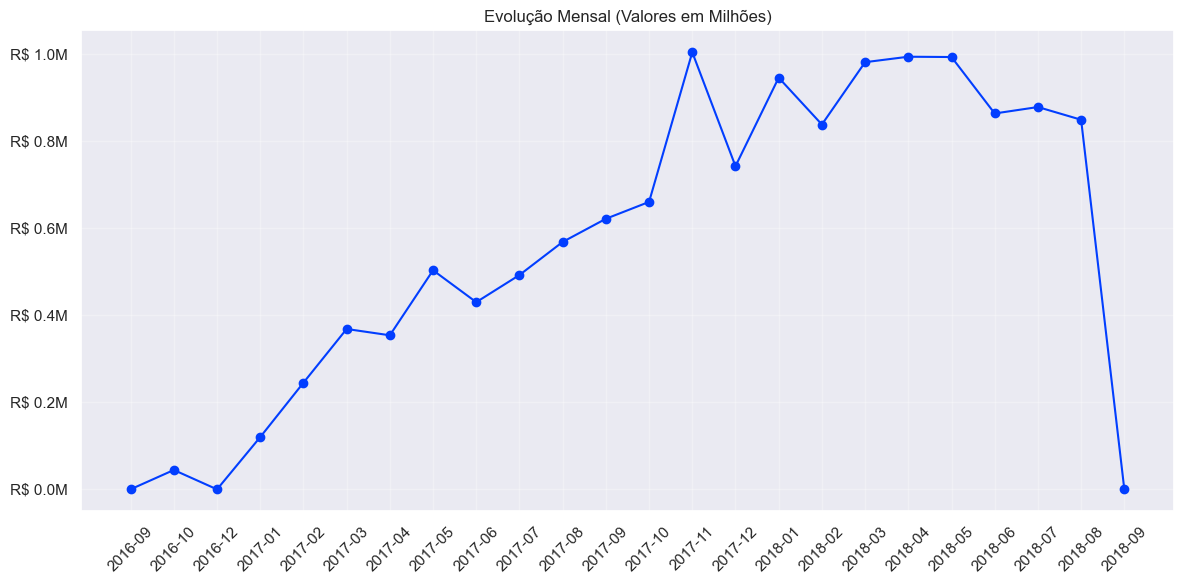

In [15]:
import matplotlib.ticker as ticker # Importante para a formatação

# 2. Agrupar por mês e somar o preço
# O 'to_period('M')' cria períodos como '2023-01', '2023-02', etc.
evolucao_mensal = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['price'].sum().reset_index()

# 3. Converter o período para string para o gráfico aceitar o eixo X
evolucao_mensal['order_purchase_timestamp'] = evolucao_mensal['order_purchase_timestamp'].astype(str)

# 4. Criar o gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(evolucao_mensal['order_purchase_timestamp'], evolucao_mensal['price'], marker='o')

# --- FORMATAÇÃO DO EIXO Y ---

# Função que recebe o valor (x) e a posição (pos)
def format_milhoes(x, pos):
    return f'R$ {x*1e-6:,.1f}M' # 1e-6 divide por 1 milhão

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_milhoes))

# ----------------------------

plt.title('Evolução Mensal (Valores em Milhões)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
df[df['order_id'] == '00143d0f86d6fbd9f9b38ab440ac16f5']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,Month_purchase,Year_purchase
41330,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06,bb8a37225e0279ac8a274c9765617eaf,74663,...,1.0,180.0,17.0,11.0,14.0,18055,sorocaba,SP,10,2017
41331,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06,bb8a37225e0279ac8a274c9765617eaf,74663,...,1.0,180.0,17.0,11.0,14.0,18055,sorocaba,SP,10,2017
41332,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06,bb8a37225e0279ac8a274c9765617eaf,74663,...,1.0,180.0,17.0,11.0,14.0,18055,sorocaba,SP,10,2017


In [17]:
mes = df['Month_purchase'] > 8
ano = df['Year_purchase'] == 2018

In [18]:
df[ano & mes]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,Month_purchase,Year_purchase
70989,54282e97f61c23b78330c15b154c867d,4b7decb9b58e2569548b8b4c8e20e8d7,shipped,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-04 15:25:00,NaT,2018-09-06,ff22e30958c13ffe219db7d711e8f564,2989,...,1.0,10400.0,16.0,68.0,32.0,9725,sao bernardo do campo,SP,9,2018


<Axes: xlabel='order_purchase_timestamp', ylabel='Count'>

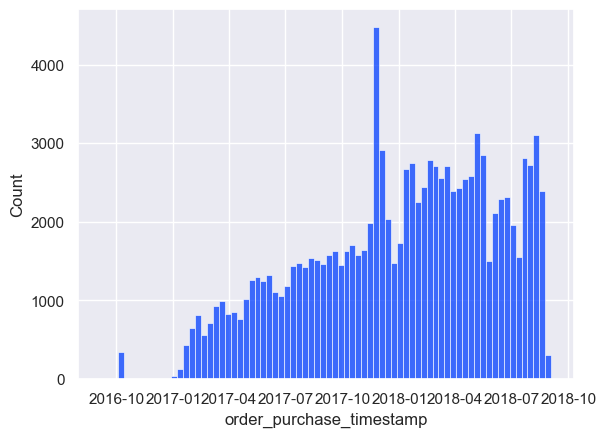

In [19]:
sns.histplot(df['order_purchase_timestamp'])

In [20]:
drop_2016 = df['Year_purchase'] == 2016

In [21]:
# Identifica os índices das linhas de 2016
indices_2016 = df[df['order_purchase_timestamp'].dt.year == 2016].index

# Remove os índices identificados
df = df.drop(indices_2016)

In [22]:
df = df[df['order_purchase_timestamp'] <= '2018-08-31']


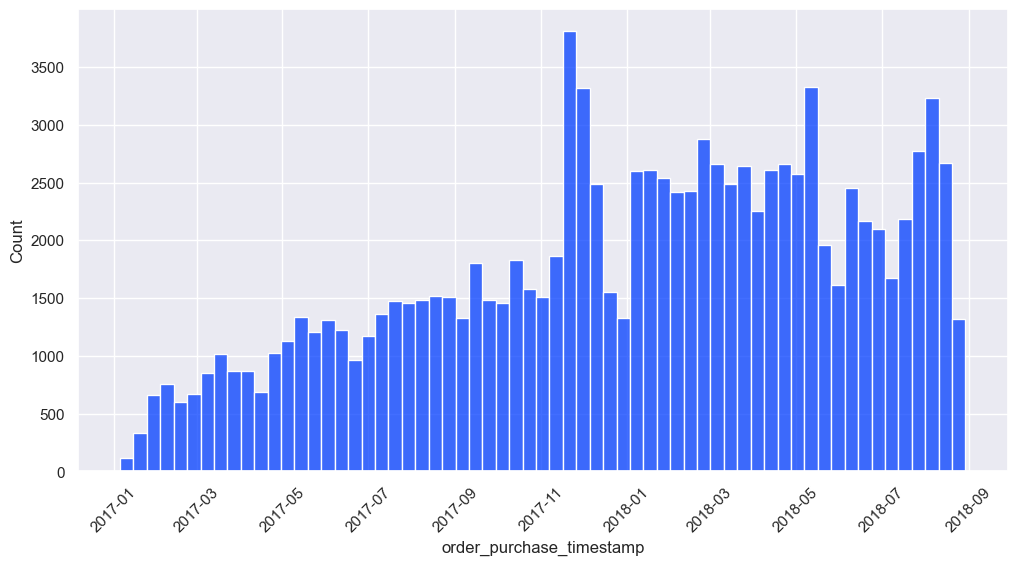

In [23]:
plt.figure(figsize= (12,6))
sns.histplot(df['order_purchase_timestamp'])
plt.xticks(rotation=45)
plt.show()

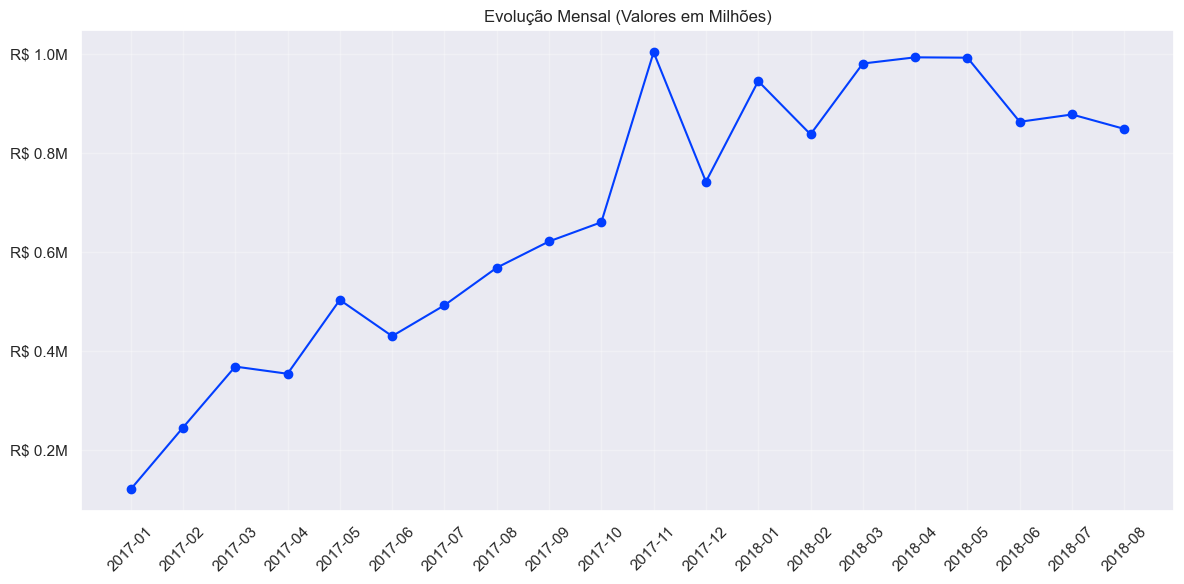

In [24]:

# 2. Agrupar por mês e somar o preço
# O 'to_period('M')' cria períodos como '2023-01', '2023-02', etc.
evolucao_mensal = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['price'].sum().reset_index()

# 3. Converter o período para string para o gráfico aceitar o eixo X
evolucao_mensal['order_purchase_timestamp'] = evolucao_mensal['order_purchase_timestamp'].astype(str)

# 4. Criar o gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(evolucao_mensal['order_purchase_timestamp'], evolucao_mensal['price'], marker='o')

# --- FORMATAÇÃO DO EIXO Y ---

# Função que recebe o valor (x) e a posição (pos)
def format_milhoes(x, pos):
    return f'R$ {x*1e-6:,.1f}M' # 1e-6 divide por 1 milhão

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_milhoes))

# ----------------------------

plt.title('Evolução Mensal (Valores em Milhões)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico mostra um forte crescimento de vendas no período e um pico de alta em novembro de 20217 devido ao período de BlackFriday

In [25]:
# 1. Agrupar por mês e calcular a soma do preço e a contagem de pedidos únicos
evolucao = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).agg({
    'price': 'sum',
    'order_id': 'nunique'
})

# 2. Calcular o ticket médio por mês
evolucao['ticket_medio'] = evolucao['price'] / evolucao['order_id']

# 3. Resetar o index para plotar
evolucao = evolucao.reset_index()
evolucao['order_purchase_timestamp'] = evolucao['order_purchase_timestamp'].astype(str)

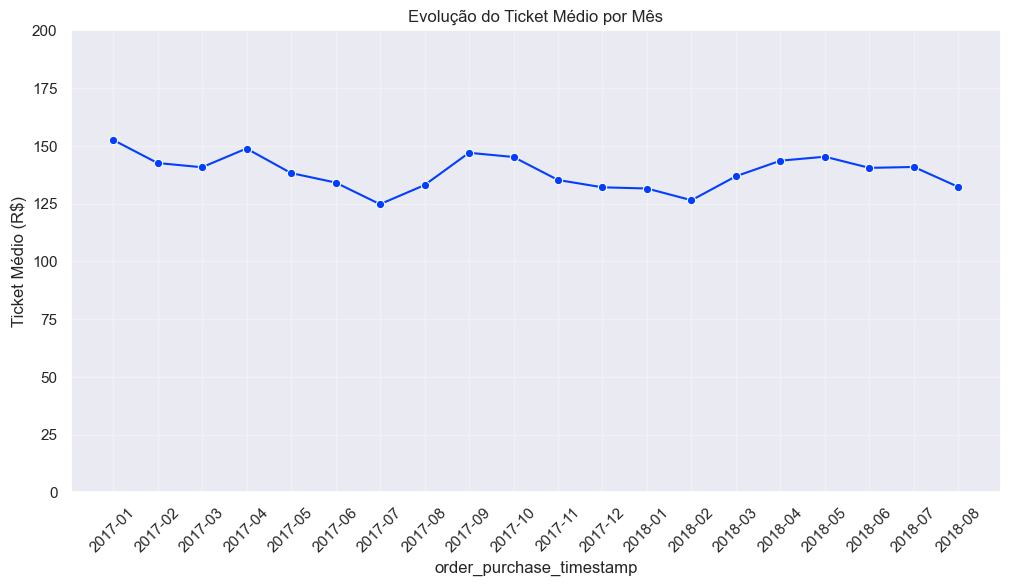

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=evolucao, x='order_purchase_timestamp', y='ticket_medio', marker='o')

plt.title('Evolução do Ticket Médio por Mês')
plt.xticks(rotation=45)
plt.ylabel('Ticket Médio (R$)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 200)
plt.show()

<Axes: xlabel='price', ylabel='product_category_name'>

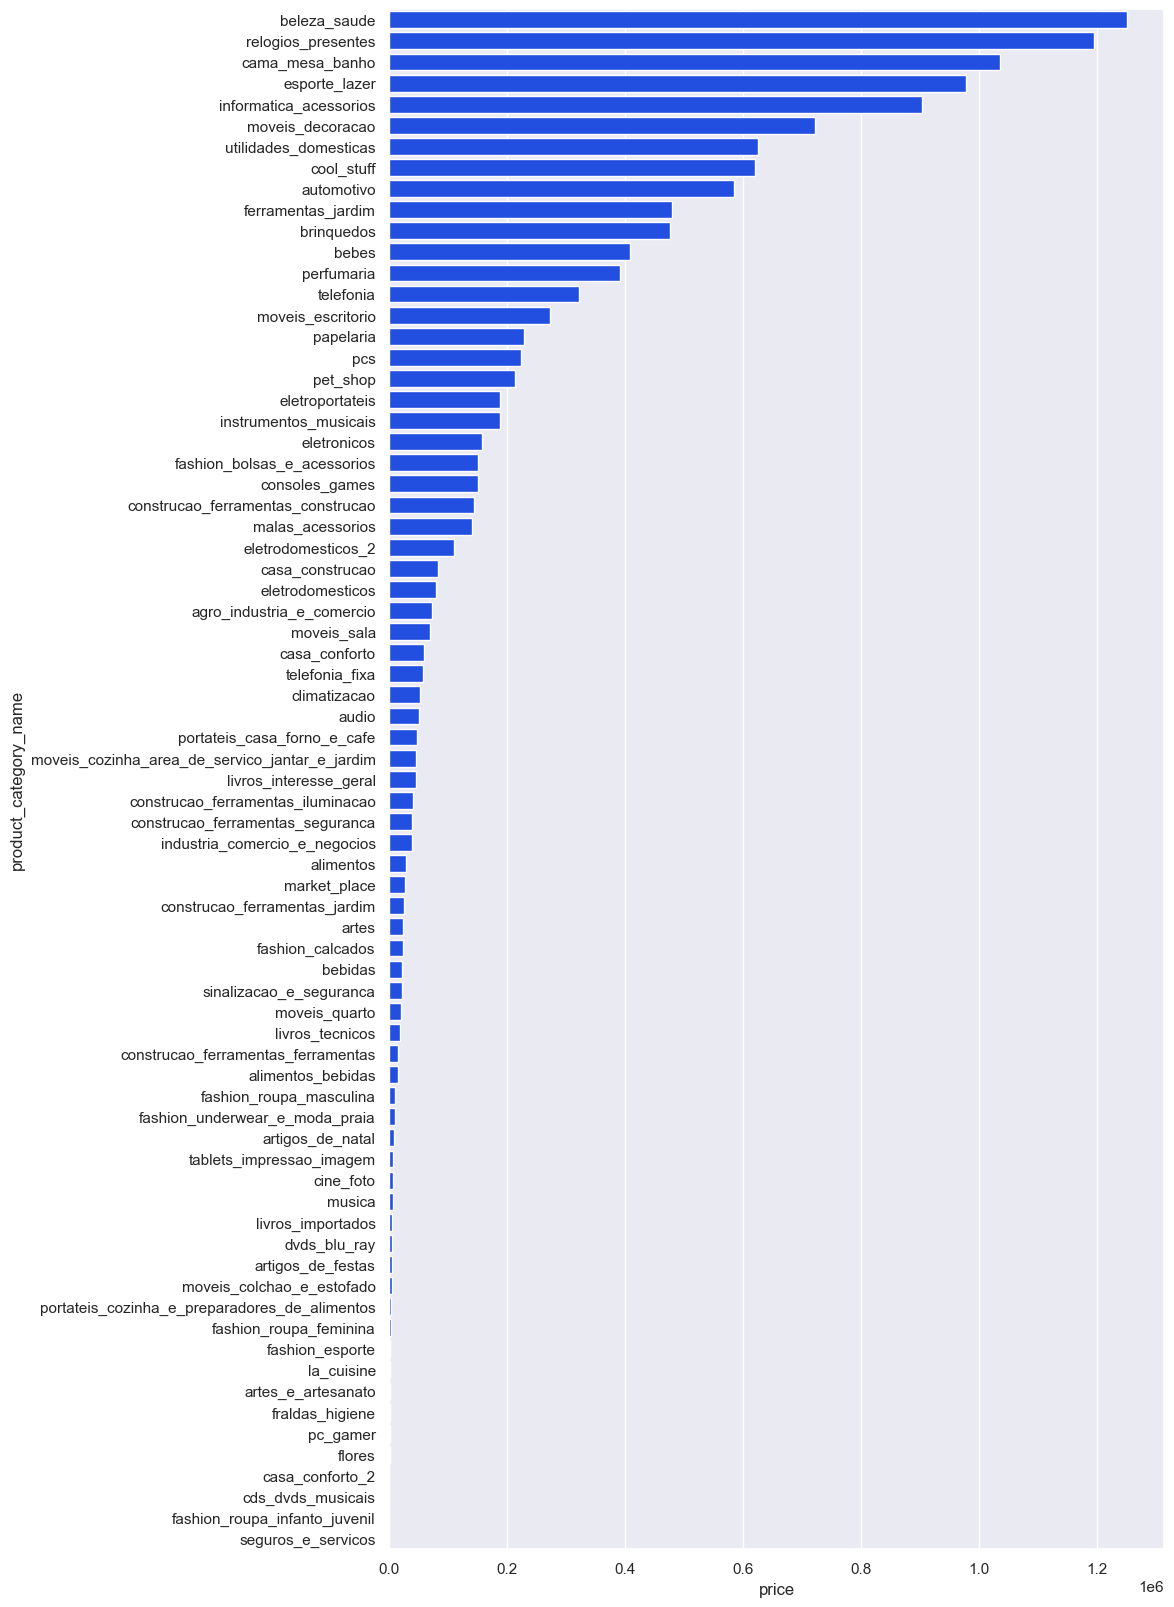

In [27]:
plt.figure(figsize = (10,20))
ordem_decrescente = df.groupby('product_category_name',observed=True)['price'].sum().sort_values(ascending=False).index
sns.barplot(data = df, y= 'product_category_name', x = 'price', errorbar = None,estimator='sum', order=ordem_decrescente)

In [28]:
# 1. Agrupar e ordenar
pareto_df = df.groupby('product_category_name', observed = False)['price'].sum().sort_values(ascending=False).reset_index()

# 2. Calcular a porcentagem individual e a acumulada
pareto_df['percentual'] = (pareto_df['price'] / pareto_df['price'].sum()) * 100
pareto_df['acumulado'] = pareto_df['percentual'].cumsum()

# Opcional: Filtrar apenas as categorias que compõem os 80% (ou as top 20 para o gráfico não poluir)
pareto_grafico = pareto_df.head(20)

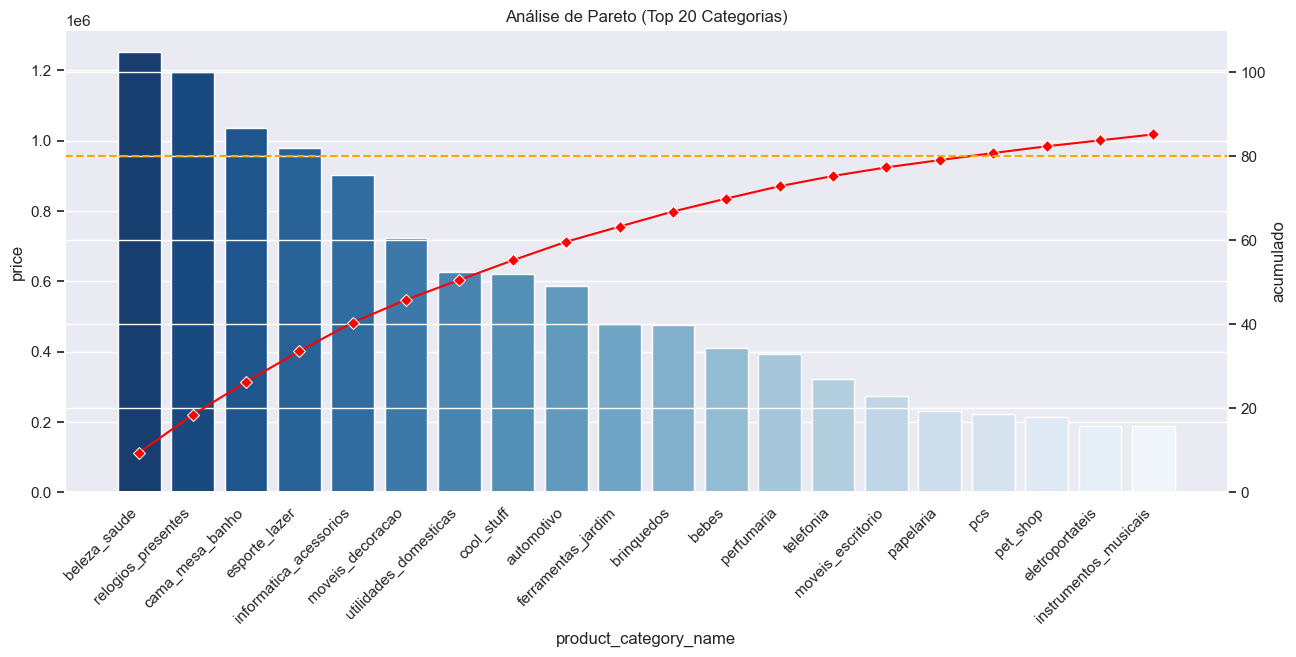

In [29]:
# 1. Agrupar, somar e ordenar de forma decrescente
pareto_df = df.groupby('product_category_name', observed=False)['price'].sum().sort_values(ascending=False).reset_index()


# 3. Calcular o acumulado
pareto_grafico['percentual'] = (pareto_grafico['price'] / pareto_df['price'].sum()) * 100
pareto_grafico['acumulado'] = pareto_grafico['percentual'].cumsum()

pareto_grafico['product_category_name'] = pareto_grafico['product_category_name'].astype(str)

# --- PLOTAGEM ---
fig, ax1 = plt.subplots(figsize=(15, 6))

sns.barplot(
    data=pareto_grafico, 
    x='product_category_name', 
    y='price', 
    ax=ax1, 
    palette='Blues_r',
    order=pareto_grafico['product_category_name'], # <--- Força a ordem do eixo X
    hue='product_category_name', # Define que a cor vem da categoria
    legend=False                 # Remove a legenda (já que o nome está no eixo X
)

plt.xticks(rotation=45, ha='right')

# Eixo secundário (linha do acumulado)
ax2 = ax1.twinx()
# Garantimos que a linha siga os mesmos pontos do eixo X
sns.lineplot(
    data=pareto_grafico, 
    x='product_category_name', 
    y='acumulado', 
    color='red', 
    marker='D', 
    ax=ax2,
    sort=False # <--- Importante: impede que a linha tente reordenar os pontos
)

ax2.set_ylim(0, 110)
ax2.axhline(80, color='orange', linestyle='--')

plt.title('Análise de Pareto (Top 20 Categorias)')
plt.show()

In [30]:
pareto_grafico

,product_category_name,price,percentual,acumulado
0,beleza_saude,1251145.54,9.427650,9.427650
1,relogios_presentes,1194824.97,9.003262,18.430912
2,cama_mesa_banho,1035485.07,7.802602,26.233513
3,esporte_lazer,977728.77,7.367396,33.600909
4,informatica_acessorios,902922.70,6.803716,40.404625
5,moveis_decoracao,721584.27,5.437292,45.841917
6,utilidades_domesticas,625538.73,4.713568,50.555485
7,cool_stuff,619724.39,4.669756,55.225241
8,automotivo,585177.48,4.409438,59.634679
9,ferramentas_jardim,479650.06,3.614266,63.248944


In [31]:
16/73

0.2191780821917808

Podemos confimar que a regra de pareto está presente nas categorias do produtos.
80% da Receita de Vendas vem do top 22% de Categoricas com maior receita de vendas acumulada.

### Onde estão os clientes? (Análise por Estado/Região).

In [32]:
# 1. Agrupar vendas por prefixo de CEP do cliente
vendas_por_cep = df.groupby('customer_zip_code_prefix')['price'].sum().reset_index()

# 2. Carregar a base de geolocalização (comum no dataset Olist)
# Esse arquivo geralmente se chama 'olist_geolocation_dataset.csv'
geo_df = pd.read_csv(geolocation)

# Limpar duplicatas de CEP na base geo (pegar a média da lat/lng para cada prefixo)
geo_df_limpo = geo_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# Converter ambos para string para garantir a compatibilidade
vendas_por_cep['customer_zip_code_prefix'] = vendas_por_cep['customer_zip_code_prefix'].astype(str)
geo_df_limpo['geolocation_zip_code_prefix'] = geo_df_limpo['geolocation_zip_code_prefix'].astype(str)

# 3. Cruzar os dados de vendas com as coordenadas
mapa_data = pd.merge(
    vendas_por_cep, 
    geo_df_limpo, 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix'
)

In [33]:
# Filtro básico para manter pontos dentro do território brasileiro
mapa_data = mapa_data[
    (mapa_data['geolocation_lat'] <= 5.27) & (mapa_data['geolocation_lat'] >= -33.75) &
    (mapa_data['geolocation_lng'] <= -34.73) & (mapa_data['geolocation_lng'] >= -73.98)
]

In [71]:
import folium
from folium.plugins import HeatMap

tamanho_mapa = {"width": 500, 'height':500}
fig = folium.Figure(**tamanho_mapa)

# Criar um mapa centralizado no Brasily
mapa = folium.Map(
    location=[-15.78, -47.93], 
    zoom_start=4, 
    tiles='StadiaStamenTonerLite',
    control_scale=True
).add_to(fig)

# Preparar os dados para o HeatMap: lista de [lat, lng, peso/faturamento]
dados_heatmap = mapa_data[['geolocation_lat', 'geolocation_lng', 'price']].values.tolist()

# Adicionar a camada de calor
HeatMap(dados_heatmap, radius=15, blur=15, max_zoom=1).add_to(mapa)

# Salvar ou exibir
mapa.save('mapa_vendas_olist.html')
mapa

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111757 entries, 0 to 113424
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       111757 non-null  string        
 1   customer_id                    111757 non-null  string        
 2   order_status                   111757 non-null  category      
 3   order_purchase_timestamp       111757 non-null  datetime64[ns]
 4   order_approved_at              111737 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111052 non-null  datetime64[ns]
 6   order_delivered_customer_date  109872 non-null  datetime64[ns]
 7   order_estimated_delivery_date  111757 non-null  datetime64[ns]
 8   customer_unique_id             111757 non-null  string        
 9   customer_zip_code_prefix       111757 non-null  string        
 10  customer_city                  111757 non-null  string        
 11  custo

### Onde estão os vendedores? (Análise por Estado/Região).

In [37]:
# 1. Agrupar vendas por prefixo de CEP do vendedor
vendedor_por_cep = df.groupby('seller_zip_code_prefix')['price'].sum().reset_index()

# 3. Cruzar os dados de vendas com as coordenadas
mapa_data_vendedor = pd.merge(
    vendedor_por_cep, 
    geo_df_limpo, 
    left_on='seller_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix'
)

In [38]:
# Filtro básico para manter pontos dentro do território brasileiro
mapa_data_vendedor = mapa_data_vendedor[
    (mapa_data_vendedor['geolocation_lat'] <= 5.27) & (mapa_data_vendedor['geolocation_lat'] >= -33.75) &
    (mapa_data_vendedor['geolocation_lng'] <= -34.73) & (mapa_data_vendedor['geolocation_lng'] >= -73.98)
]

In [39]:
import folium
from folium.plugins import HeatMap

# Criar um mapa centralizado no Brasily
mapa_vendedor = folium.Map(location=[-15.78, -47.93], zoom_start=4, tiles='cartodbpositron')

# Preparar os dados para o HeatMap: lista de [lat, lng, peso/faturamento]
dados_heatmap = mapa_data_vendedor[['geolocation_lat', 'geolocation_lng', 'price']].values.tolist()

# Adicionar a camada de calor
HeatMap(dados_heatmap, radius=20, blur=20, max_zoom=1).add_to(mapa_vendedor)

# Salvar ou exibir
mapa_vendedor.save('mapa_vendas_olist.html')

In [40]:
mapa_vendedor

In [41]:
df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,Month_purchase,Year_purchase
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,9350,maua,SP,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP,7,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP,8,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,3.0,450.0,30.0,10.0,20.0,31842,belo horizonte,MG,11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,4.0,250.0,51.0,15.0,15.0,8752,mogi das cruzes,SP,2,2018
